# Step 6 - property feature analysis

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
merged_data = pd.read_csv('../data/curated/merged_data/merged_data.csv')

In [7]:
merged_data.head()

,name,rental_price,num_bedroom,num_bathroom,num_parking,postcode,coordinates,property_geometry,sa2_code,sa2_name,sa2_geometry,personal_income,avg_income_growth_rate(%),2021_population,avg_pop_growth_rates(%),crime_rate(%)
0,31 Chittagong Drive Clyde North VIC 3978,575.0,4,2,2.0,3978.0,"[-38.1053122, 145.3570863]",POINT (145.3570863 -38.1053122),212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,68495.004299,3.028540,15038.0,129.962525,0.122595
1,50 Elmtree Crescent Clyde North VIC 3978,560.0,4,2,2.0,3978.0,"[-38.0825712, 145.3561984]",POINT (145.3561984 -38.0825712),212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,68495.004299,3.028540,10652.0,29.771333,0.122595
2,7 Mortdale Lane Clyde North VIC 3978,490.0,2,2,1.0,3978.0,"[-38.0961758, 145.3800644]",POINT (145.3800644 -38.0961758),212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,68495.004299,3.028540,15038.0,129.962525,0.122595
3,54 Walhallow Drive Clyde North VIC 3978,540.0,4,2,1.0,3978.0,"[-38.1133324, 145.3457396]",POINT (145.3457396 -38.1133324),212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,68495.004299,3.028540,15038.0,129.962525,0.122595
4,10 Sicily Road Clyde North VIC 3978,520.0,4,2,2.0,3978.0,"[-38.1295789, 145.3642993]",POINT (145.3642993 -38.1295789),212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,67445.099591,2.233051,17641.0,14.250357,0.197962


## 1. Correlation of continuous property features

### 1.1 Pair plot for continous features

In [23]:
continuous_property_feature_list = ['num_bedroom', 'num_bathroom', 'num_parking', 'rental_price']

/home/zyyin1/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


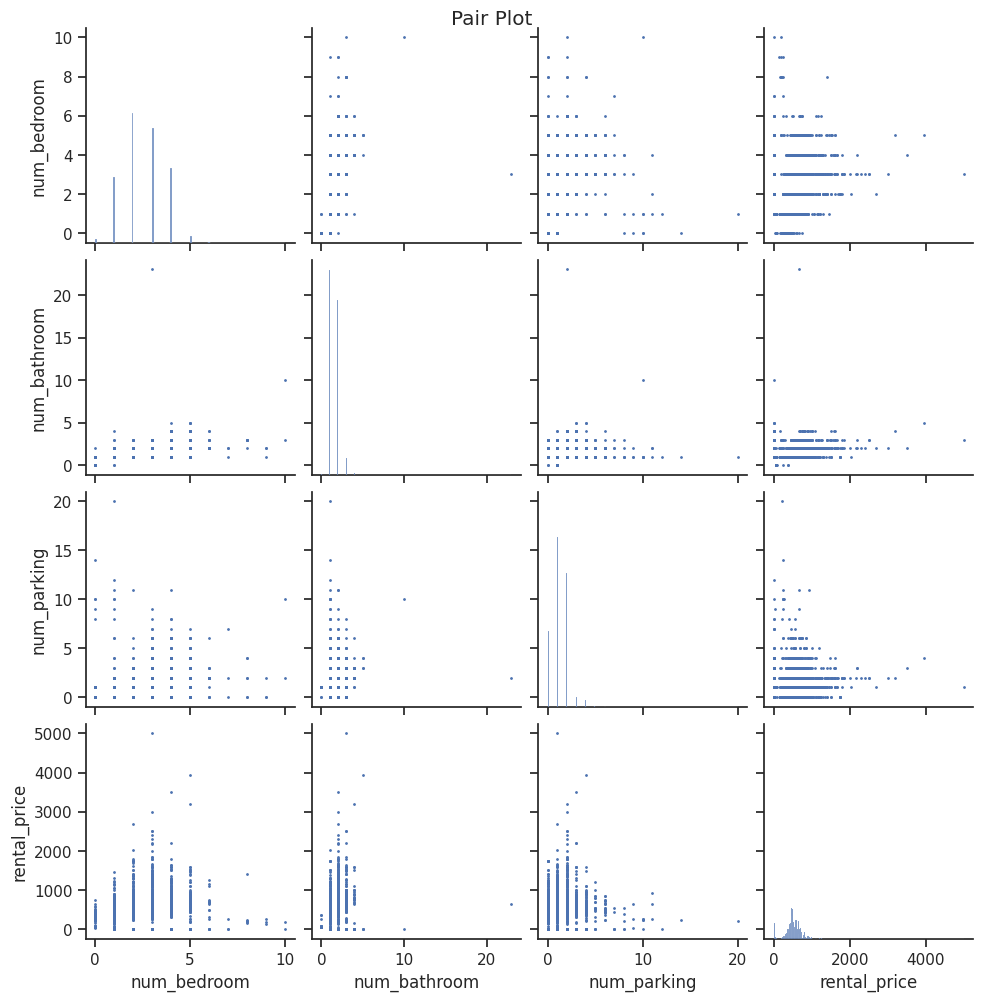

In [24]:
sns.set(style="ticks", color_codes=True)

pair_plot = sns.pairplot(
    merged_data[continuous_property_feature_list], 
    plot_kws=dict(s=1, edgecolor="b", linewidth=1)
)
pair_plot.fig.suptitle(f"Pair Plot", y = 1)

# plt.savefig('../plots/pair_plot_for_continuous_features')
plt.show()

### 1.2 Heat map with pearson correlation for continous features

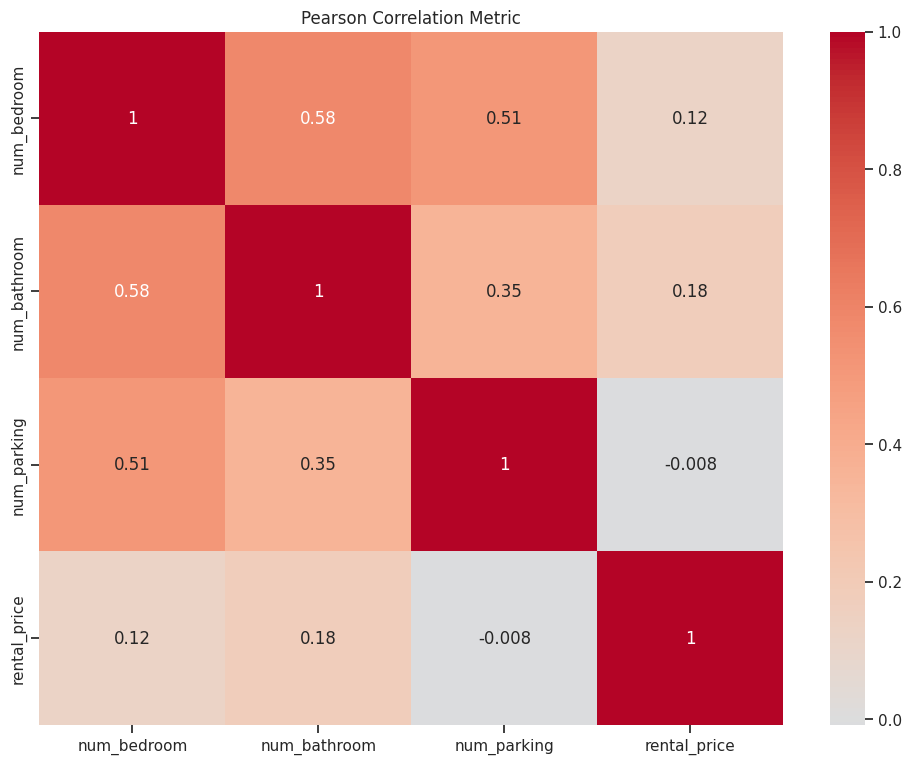

In [16]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    merged_data[continuous_property_feature_list].corr(), 
    annot=True, 
    cmap='coolwarm', 
    center=0
)
plt.title('Pearson Correlation Metric')

# plt.savefig('../plots/head_plot_for_continuous_features')
plt.show()


### 1.2 Heat map with spearman correlation for continous features

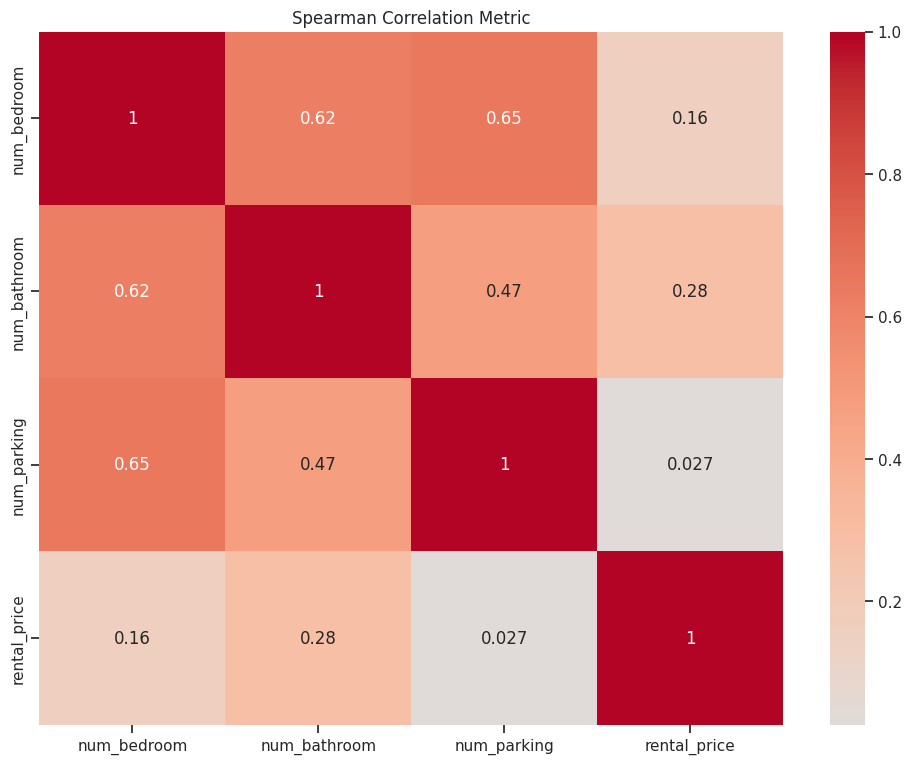

In [17]:
# Use spearman correlation coefficient
spearman_corr = merged_data[continuous_property_feature_list].corr(method='spearman')

plt.figure(figsize=(12, 9))

sns.heatmap(
    spearman_corr, 
    annot=True, 
    cmap='coolwarm', 
    center=0
)
plt.title('Spearman Correlation Metric')

# plt.savefig('../plots/head_plot_with_spearman_for_continuous_features')
plt.show()

## 2. Correlation of discrete property features

2-way ANOVA for 2 discrete features: 'postcode' & 'sa2_name'

In [20]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [22]:
# Build a linear regression model using Ordinary Least Squares without interaction
model = ols(
    f'rental_price ~ postcode + sa2_name',  # Notice the use of '+' instead of '*'
    data = merged_data
).fit()

# Create the ANOVA table for the given model
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                sum_sq      df         F        PR(>F)
sa2_name  5.107035e+07   355.0  2.829110  2.411234e-58
postcode  3.327170e+05     1.0  6.543113  1.054641e-02
Residual  4.290211e+08  8437.0       NaN           NaN


The rental price for segmentation based on 'sa2_name' is much more significant.